# Cats vs Dogs With a CNN

This notebook adapts the CNN idea from the previous MNIST class to a binary image classification problem.

Main changes relative to MNIST:
- RGB images instead of grayscale
- Larger inputs
- Binary output
- A validation split to monitor overfitting

## Expected Folder Structure

```
cats_dogs_subset/
  train/
    cats/
    dogs/
  val/
    cats/
    dogs/
  test/
    cats/
    dogs/
```


In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

seed = 42
random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
data_dir = Path("cats_dogs_subset")
train_dir = data_dir / "train"
val_dir = data_dir / "val"
test_dir = data_dir / "test"

image_size = 128
input_channels = 3
num_classes = 1  # Binary classification: cat vs dog
batch_size = 32
num_workers = 0
learning_rate = 1e-3
num_epochs = 30

limit_train_per_class = 750
limit_val_per_class = 200
limit_test_per_class = 200

for split_dir in (train_dir, val_dir, test_dir):
    if not split_dir.exists():
        raise FileNotFoundError(
            f"Missing folder: {split_dir}\n"
            "Create train/val/test folders with one subfolder per class before running the notebook."
        )

print(f"Dataset root: {data_dir.resolve()}")

Dataset root: C:\Users\nunoa\Desktop\aulas\lcc\modulo2\praticas\pratica4\part1_CNNs\cats_dogs_subset


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])

In [4]:
def make_balanced_subset(dataset, limit_per_class=None):
    if limit_per_class is None:
        return dataset

    selected_indices = []
    counts = {class_idx: 0 for class_idx in range(len(dataset.classes))}

    for index, (_, class_idx) in enumerate(dataset.samples):
        if counts[class_idx] < limit_per_class:
            selected_indices.append(index)
            counts[class_idx] += 1

        if all(count == limit_per_class for count in counts.values()):
            break

    return Subset(dataset, selected_indices)


full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
full_val_dataset = datasets.ImageFolder(val_dir, transform=eval_transform)
full_test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

train_dataset = make_balanced_subset(full_train_dataset, limit_train_per_class)
val_dataset = make_balanced_subset(full_val_dataset, limit_val_per_class)
test_dataset = make_balanced_subset(full_test_dataset, limit_test_per_class)

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

class_names = full_train_dataset.classes
class_to_idx = full_train_dataset.class_to_idx

print(f"Classes: {class_names}")
print(f"Class to index: {class_to_idx}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Classes: ['cats', 'dogs']
Class to index: {'cats': 0, 'dogs': 1}
Training samples: 1500
Validation samples: 400
Test samples: 400


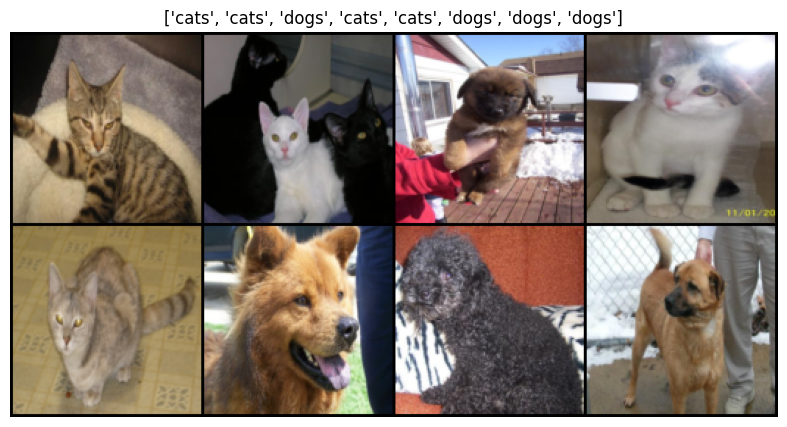

In [5]:
images, labels = next(iter(trainloader))
grid = make_grid(images[:8], nrow=4)

plt.figure(figsize=(10, 5))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title([class_names[label.item()] for label in labels[:8]])
plt.show()

## CNN Model

The model below stays close to the previous CNN idea: convolution, ReLU, pooling, and then a classifier.

Because this is a binary problem, the last layer has:
- one output neuron
- sigmoid activation
- BCELoss during training

In [30]:
class CatsDogsCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),     #(32, 128, 128)
            nn.ReLU(),
            nn.MaxPool2d(2),                                #(32, 64, 64)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),    #(64, 64, 64)
            nn.ReLU(),
            nn.MaxPool2d(2),                                #(64, 32, 32)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),   #(128, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(2),                        #(128, 16, 16)
            nn.Dropout2d(0.3)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)


model = CatsDogsCNN().to(device)
print(model)

CatsDogsCNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.3, inplace=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [31]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [32]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_training:
                loss.backward()
                optimizer.step()

        predictions = (outputs >= 0.5).float()
        total_loss += loss.item() * images.size(0)
        total_correct += (predictions == labels).sum().item()
        total_examples += images.size(0)

    average_loss = total_loss / total_examples
    accuracy = total_correct / total_examples
    return average_loss, accuracy

In [33]:
best_val_loss = float("inf")
best_model_path = "best_model.pth"

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = run_epoch(model, trainloader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, valloader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f} | val acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

model.load_state_dict(torch.load(best_model_path))
print(f"Best model loaded (val_loss={best_val_loss:.4f}).")

Epoch 01/30 | train loss: 0.7059 | train acc: 0.5367 | val loss: 0.6867 | val acc: 0.5325
Epoch 02/30 | train loss: 0.6836 | train acc: 0.5660 | val loss: 0.6895 | val acc: 0.5550
Epoch 03/30 | train loss: 0.6757 | train acc: 0.5827 | val loss: 0.6680 | val acc: 0.6000
Epoch 04/30 | train loss: 0.6669 | train acc: 0.6007 | val loss: 0.6574 | val acc: 0.6175
Epoch 05/30 | train loss: 0.6477 | train acc: 0.6287 | val loss: 0.6576 | val acc: 0.6075
Epoch 06/30 | train loss: 0.6288 | train acc: 0.6407 | val loss: 0.6457 | val acc: 0.6575
Epoch 07/30 | train loss: 0.6165 | train acc: 0.6767 | val loss: 0.6109 | val acc: 0.6600
Epoch 08/30 | train loss: 0.5891 | train acc: 0.6993 | val loss: 0.6290 | val acc: 0.6550
Epoch 09/30 | train loss: 0.5656 | train acc: 0.7060 | val loss: 0.5983 | val acc: 0.6950
Epoch 10/30 | train loss: 0.5524 | train acc: 0.7160 | val loss: 0.5794 | val acc: 0.6875
Epoch 11/30 | train loss: 0.5403 | train acc: 0.7253 | val loss: 0.5616 | val acc: 0.7175
Epoch 12/3

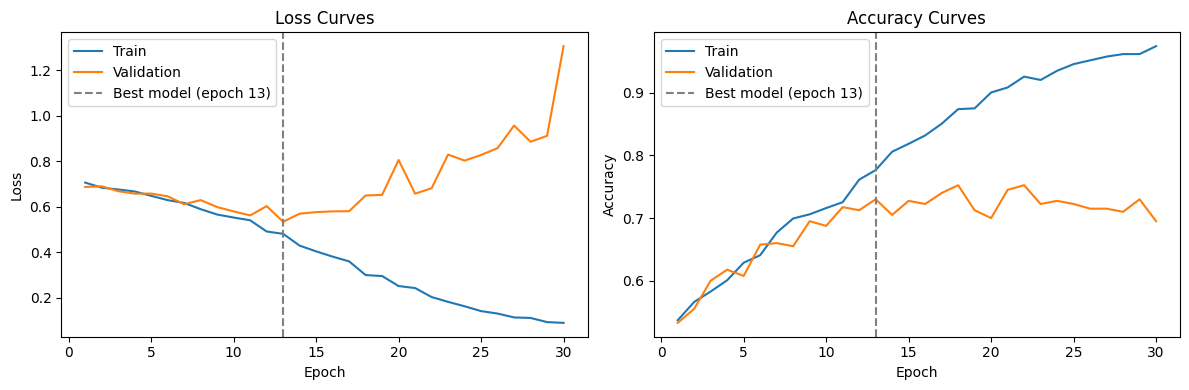

In [34]:
epochs = range(1, len(history["train_loss"]) + 1)
best_epoch = history["val_loss"].index(min(history["val_loss"])) + 1

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train")
plt.plot(epochs, history["val_loss"], label="Validation")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best model (epoch {best_epoch})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train")
plt.plot(epochs, history["val_acc"], label="Validation")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best model (epoch {best_epoch})")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
test_loss, test_acc = run_epoch(model, testloader, criterion)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.5868
Test accuracy: 0.7050
